In [1]:
import tensorflow as tf
import torch
import torchvision
from torch.utils.data import IterableDataset, DataLoader
from matplotlib import pyplot as plt
import numpy as np
import torch.nn as nn
from PIL import Image
def parse_tfrecord(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'class': tf.io.FixedLenFeature([], tf.int64),
        'id' : tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.image.decode_jpeg(parsed['image'], channels=3)
    image = tf.image.resize(image, [224, 224])
    #image = tf.image.convert_image_dtype(image, tf.float32)
    label = parsed['class']
    idd = parsed['id']
    return image, label,idd

def load_tfrecord_dataset(pattern):
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise ValueError(f"No files found for pattern {pattern}")
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(parse_tfrecord)
    # 可选：打乱、批处理等，但此处我们只返回样本级别的数据集
    return dataset

class TFRecordToPyTorch(IterableDataset):
    def __init__(self, tfrecord_pattern,transform=None):
        self.tfrecord_pattern = tfrecord_pattern
        self.transform=transform

    def __iter__(self):
        # 每次迭代创建新的数据集，保证可重复使用
        dataset = load_tfrecord_dataset(self.tfrecord_pattern)
        # 使用 as_numpy_iterator() 获取 NumPy 数组，便于转换为 PyTorch 张量
        for image_np, label_np,idd in dataset.as_numpy_iterator():
            # image_np shape: (224,224,3), dtype float32, label_np scalar int64
            # 转为 PyTorch 张量，并调整为 CxHxW
            image_pil = Image.fromarray((image_np).astype('uint8')) 
            if self.transform:
                image_tensor = self.transform(image_pil)
            else:
                # 如果不需要 transform，至少转为 tensor
                image_tensor = torch.from_numpy(image_np).permute(2,0,1)
            #image_torch = torch.from_numpy(image_np).permute(2, 0, 1)  # (3,224,224)
            label_torch = torch.tensor(label_np, dtype=torch.long)
            id_torch = idd
            yield image_tensor, label_torch,id_torch




In [2]:
from transformers import ViTForImageClassification, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 

model_name = "google/vit-base-patch16-224-in21k"  # 在ImageNet21k上预训练

model = ViTForImageClassification.from_pretrained(model_name, num_labels=104)
 
model.to(device)
 
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
print(model,feature_extractor)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

I0000 00:00:1783601419.561283      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13374 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783601419.563618      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


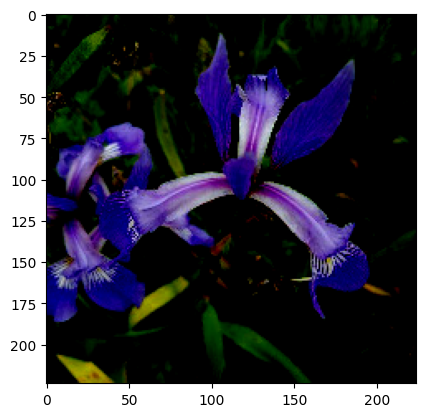

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),  # 调整尺寸为224x224
    torchvision.transforms.ToTensor(),  # 转换为张量
    # 使用特征提取器的参数进行标准化
    torchvision.transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/train/*'
dataset = TFRecordToPyTorch(tfrecord_path,transform)
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/val/*'
dataset2 = TFRecordToPyTorch(tfrecord_path,transform)
# 可以配合 DataLoader 使用
train_dataloader = DataLoader(dataset, batch_size=32, num_workers=0)  # num_workers 设为0，因为 TF 数据集内部已并行
val_dataloader = DataLoader(dataset2, batch_size=32, num_workers=0)
for batch in train_dataloader:
    plt.imshow(batch[0][1].permute(1,2,0).numpy())
    break
    plt.axis('off')
    plt.show()

In [4]:
!pip install torchao==0.16.0
from peft import LoraConfig, get_peft_model

# 加载预训练模型
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

# 修改分类器的输出维度
model.classifier = torch.nn.Linear(model.classifier.in_features, 104)
target_layers = [5,7,9,11]  # 指定要应用 LoRA 的层索引
target_modules = []
for layer in target_layers:
    target_modules.append(f"encoder.layer.{layer}.attention.attention.query")
    target_modules.append(f"encoder.layer.{layer}.attention.attention.value")
# 配置 LoRA
config = LoraConfig(
    r=8,  # LoRA 的秩
    lora_alpha=16,  # LoRA 的缩放因子
    target_modules=target_modules,  # 目标模块
    lora_dropout=0.1,  # Dropout 概率
    bias="none",  # 是否更新偏置
    modules_to_save=["classifier"],  # 指定分类器需要被微调
)

# 封装为 LoRA 模型
model = get_peft_model(model, config)

# 验证分类器是否被微调
print("验证分类器参数是否被训练:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: requires_grad = {param.requires_grad}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 4.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

验证分类器参数是否被训练:
base_model.model.vit.encoder.layer.5.attention.attention.query.lora_A.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.5.attention.attention.query.lora_B.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.5.attention.attention.value.lora_A.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.5.attention.attention.value.lora_B.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.7.attention.attention.query.lora_A.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.7.attention.attention.query.lora_B.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.7.attention.attention.value.lora_A.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.7.attention.attention.value.lora_B.default.weight: requires_grad = True
base_model.model.vit.encoder.layer.9.attention.attention.query.lora_A.default.weight: requires_grad = True
base_model.model.vit.en

In [5]:
@torch.no_grad()
def validate(model,loader):
    model.eval()
    acc=0
    total=0
    for batch in loader:
        X = batch[0]
        labels = batch[1]
        X = X.to(device)
        labels = labels.to(device)
        pred=torch.argmax(model(X).logits,dim=1)
        acc+=pred.eq(labels).sum()
        total+=labels.size(0)
    print(f"acc:{acc/total}")
    return acc/total
from tqdm import tqdm   
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=model.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
epochs = 30
best_acc=0.0
for epoch in range(epochs):
    model.train()
    training_loss = 0
    
    # 使用 tqdm 包装 dataloader，并设置描述信息
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    lens=0
    for batch in progress_bar:
        optimizer.zero_grad()
        X = batch[0].to(device)
        labels = batch[1].to(device)
        
        outputs = model(X).logits
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        
        training_loss += loss.item()
        lens+=1
        # 更新进度条显示当前 batch 的损失
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{training_loss / (progress_bar.n+1):.4f}'  # progress_bar.n 是已处理 batch 数
        })
    
    scheduler.step()
    
    avg_train_loss = training_loss / lens
    print(f"Epoch {epoch+1} train_loss: {avg_train_loss:.4f}")
    
    # 验证（你也可以为验证添加进度条，见下方建议）
    current_acc=validate(model, val_dataloader)
    if current_acc > best_acc :
        torch.save(model.state_dict(), 'model.pth')
        print(f"best model save,acc:{current_acc}")
        best_acc=current_acc

Epoch 1/10: 399it [04:33,  1.46it/s, loss=0.6496, avg_loss=1.2149]


Epoch 1 train_loss: 1.2149
acc:0.9571659564971924
best model save,acc:0.9571659564971924


Epoch 2/10: 23it [00:16,  1.40it/s, loss=0.3227, avg_loss=0.2330]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
def parse_tfrecord_test(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'id' : tf.io.FixedLenFeature([], tf.string)
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.image.decode_jpeg(parsed['image'], channels=3)
    image = tf.image.resize(image, [224, 224])
    #image = tf.image.convert_image_dtype(image, tf.float32)
    idd = parsed['id']
    return image,idd
def load_tfrecord_dataset_test(pattern):
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise ValueError(f"No files found for pattern {pattern}")
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(parse_tfrecord_test)
    # 可选：打乱、批处理等，但此处我们只返回样本级别的数据集
    return dataset
class TFRecordToPyTorchTest(IterableDataset):
    def __init__(self, tfrecord_pattern,transform=None):
        self.tfrecord_pattern = tfrecord_pattern
        self.transform=transform

    def __iter__(self):
        # 每次迭代创建新的数据集，保证可重复使用
        dataset = load_tfrecord_dataset_test(self.tfrecord_pattern)
        # 使用 as_numpy_iterator() 获取 NumPy 数组，便于转换为 PyTorch 张量
        for image_np,idd in dataset.as_numpy_iterator():
            # image_np shape: (224,224,3), dtype float32, label_np scalar int64
            # 转为 PyTorch 张量，并调整为 CxHxW
            image_pil = Image.fromarray((image_np).astype('uint8')) 
            if self.transform:
                image_tensor = self.transform(image_pil)
            else:
                # 如果不需要 transform，至少转为 tensor
                image_tensor = torch.from_numpy(image_np).permute(2,0,1)
            #image_torch = torch.from_numpy(image_np).permute(2, 0, 1)  # (3,224,224)
            #label_torch = torch.tensor(label_np, dtype=torch.long)
            id_torch = idd
            yield image_tensor,id_torch
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/test/*'
dataset3 = TFRecordToPyTorchTest(tfrecord_path,transform)
test_dataloader = DataLoader(dataset3, batch_size=32, num_workers=0)
id_array=[]
all_preds=[]
model.load_state_dict(torch.load('model.pth'))
model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        idd = batch[1]
        outputs = model(input_ids).logits
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        id_array.extend(idd)
submission = pd.DataFrame({
    'id':id_array,
    'label': all_preds
})


In [ ]:
submission['id'] = submission['id'].apply(lambda x: x.decode('utf-8'))
print(submission)
submission.to_csv('submission.csv', index=False)
print("Submission saved!")